# Let's make PSF so we can try something in 3D

Text(0.5, 0.98, 'Gibson Lanni PSF NA=1.4, xy px sz 0.09 μm, z step 0.3 μm, gamma=0.2')

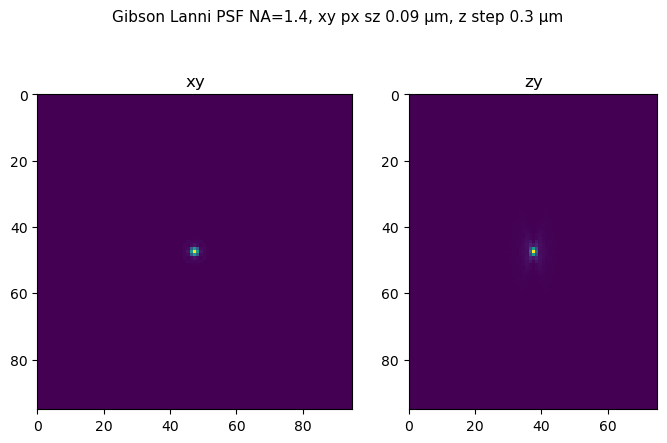

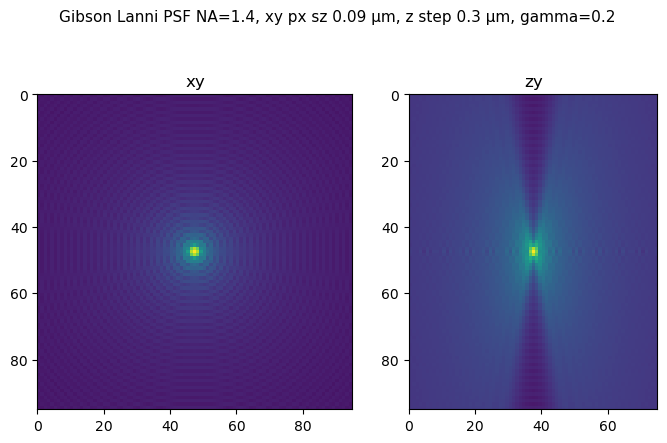

In [10]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.plotting.projections import show_xy_zy_slice_center
import numpy as np
import matplotlib.pyplot as plt

xy_psf_dim = 95
NA = 1.4
x_voxel_size = 0.090
z_voxel_size = 0.3
z_psf_dim = 75
wl = .500
ni = 1.5
ns = 1.5
defocus = 0

psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wl, use_psfm=True)
psf = np.squeeze(psf.astype('float32'))

from tnia.plotting.projections import show_xy_zy_slice_center

fig = show_xy_zy_slice_center(psf, figsize=(8, 5))
fig.suptitle(f'Gibson Lanni PSF NA={1.4}, xy px sz {x_voxel_size} μm, z step {z_voxel_size} μm', fontsize=11)
fig = show_xy_zy_slice_center(psf, gamma=0.2, figsize=(8, 5))
fig.suptitle(f'Gibson Lanni PSF NA={1.4}, xy px sz {x_voxel_size} μm, z step {z_voxel_size} μm, gamma=0.2', fontsize=11)




## Point sphere pancake

Point, sphere, pancake

Phantom shape after downscale: (129, 129, 129)


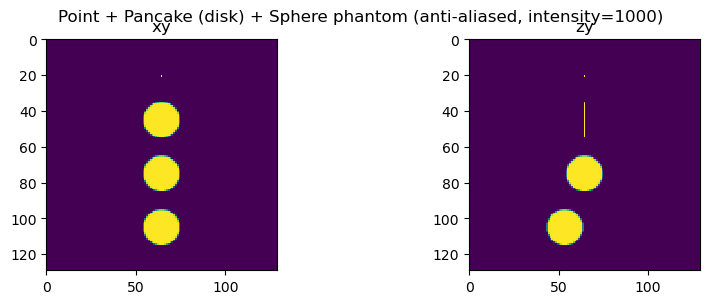

In [11]:
from tnia.plotting.projections import show_xy_zy_max
from skimage.transform import downscale_local_mean

scale = 5
z_dim = 129
y_dim = 129
x_dim = 129
intensity = 1000000

# draw at 10x resolution in xy, then downscale
z_hi = z_dim * scale
y_hi = y_dim * scale
x_hi = x_dim * scale

phantom_hi = np.zeros((z_hi, y_hi, x_hi), dtype=np.float32)
zc_hi = z_hi // 2
xc_hi = x_hi // 2
y1_hi = 20 * scale
y2_hi = 45 * scale
y3_hi = 75 * scale
y4_hi = 105 * scale

zz, yy, xx = np.ogrid[:z_hi, :y_hi, :x_hi]

# 1. single point (small dot at 10x)
phantom_hi[zc_hi, y1_hi, xc_hi] = intensity * scale * scale * scale

# 2. pancake/disk: single z plane, radius 10 * scale
disk_xy_radius = 10 * scale
dist_disk = np.sqrt((xx - xc_hi)**2 + (yy - y2_hi)**2)
phantom_hi[(zz == zc_hi) & (dist_disk <= disk_xy_radius)] = intensity * scale 

# 3. sphere: radius 10 * scale
sphere_radius = 10 * scale
dist_sphere = np.sqrt((zz - zc_hi)**2 + (yy - y3_hi)**2 + (xx - xc_hi)**2)
phantom_hi[dist_sphere <= sphere_radius] = intensity

# 4. sphere out of focus: radius 10 * scale
sphere_radius = 10 * scale
zc_defocus_hi = zc_hi- sphere_radius - 5
dist_sphere = np.sqrt((zz - zc_defocus_hi)**2 + (yy - y4_hi)**2 + (xx - xc_hi)**2)
phantom_hi[dist_sphere <= sphere_radius] = intensity


# downscale 
phantom = downscale_local_mean(phantom_hi, (scale, scale, scale)).astype(np.float32)

xc = x_dim // 2
print(f'Phantom shape after downscale: {phantom.shape}')
fig = show_xy_zy_max(phantom)
fig.suptitle('Point + Pancake (disk) + Sphere phantom (anti-aliased, intensity=1000)')
plt.show()

## Now lets convolve them

189817.5 4.984475
189817.5 4.984475


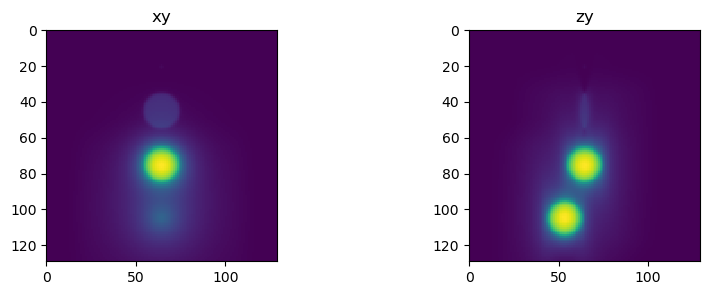

In [12]:
from tnia.deconvolution.forward import forward 

image = forward(phantom, psf, 5, add_poisson=False, gpu=True)
print(image.max(), image.min())
image[image<0]=0
image[image<0]=0
print(image.max(), image.min())

fig = show_xy_zy_slice_center(image)

# Try 3 decon methods

1.  2D
2.  3D PSF and solution space but 2D input
3.  Full 3D

In [18]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp

iterations = 2500

print('--- Running 2D decon ---')
input_slice = image[image.shape[0]//2, :, :]
psf_2d = psf[psf.shape[0]//2] / psf[psf.shape[0]//2].sum()
deconvolved_2d = richardson_lucy_cp(input_slice, psf_2d, iterations)

print()
print('--- Running 2D slice → 3D decon ---')
# add trivial dimension
input_slice = input_slice[np.newaxis, :, :]
deconvolved_2d_3d = richardson_lucy_cp(input_slice, psf, iterations, noncirc=True, do_unpad=True)
deconvolved_2d_3d[deconvolved_2d_3d<0]=0

print()
print('--- Running full 3D decon ---')

deconvolved_3d = richardson_lucy_cp(image, psf, iterations, noncirc=True)


--- Running 2D decon ---
Input size: (129, 129), PSF size: (95, 95)
Input is 2D, PSF is 2D

0# 250# 500# 750# 1000# 1250# 1500# 1750# 2000# 2250# 

--- Running 2D slice → 3D decon ---
Input size: (1, 129, 129), PSF size: (75, 95, 95)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0# 250# 500# 750# 1000# 1250# 1500# 1750# 2000# 2250# 

--- Running full 3D decon ---
Input size: (129, 129, 129), PSF size: (75, 95, 95)

0# 250# 500# 750# 1000# 1250# 1500# 1750# 2000# 2250# 


## Take a look at results

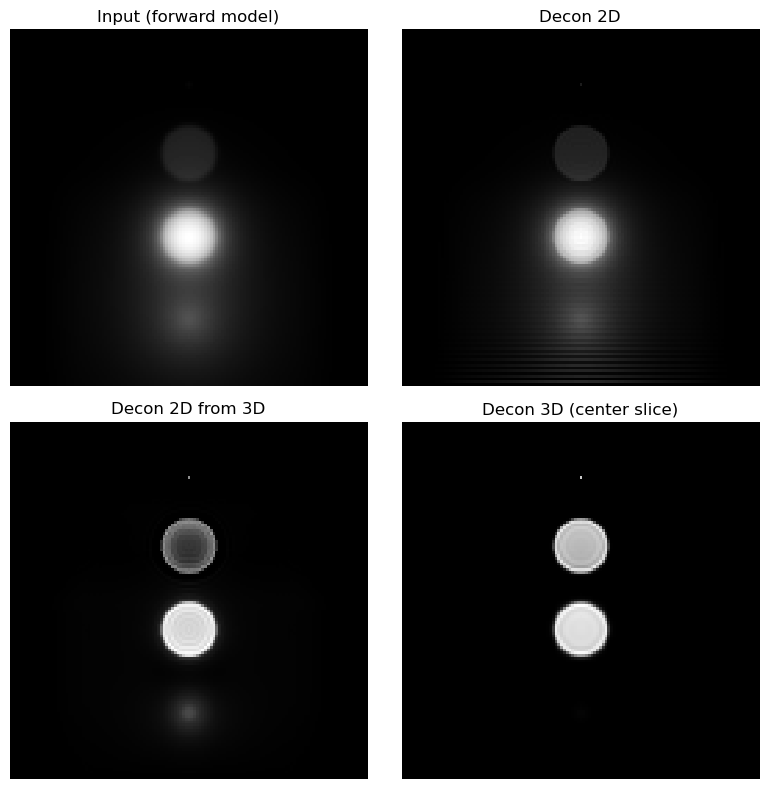

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(input_slice.squeeze(), cmap='gray')
axes[0, 0].set_title('Input (forward model)')
axes[0, 0].axis('off')
axes[0, 1].imshow(deconvolved_2d.squeeze(), cmap='gray')
axes[0, 1].set_title('Decon 2D')
axes[0, 1].axis('off')
axes[1, 0].imshow(deconvolved_2d_3d.squeeze(), cmap='gray')
axes[1, 0].set_title('Decon 2D from 3D')
axes[1, 0].axis('off')
axes[1, 1].imshow(deconvolved_3d[deconvolved_3d.shape[0]//2], cmap='gray')
axes[1, 1].set_title('Decon 3D (center slice)')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [20]:
# 2d power spectrum


((129, 129, 129), (129, 129), (1, 129, 129), (129, 129, 129))

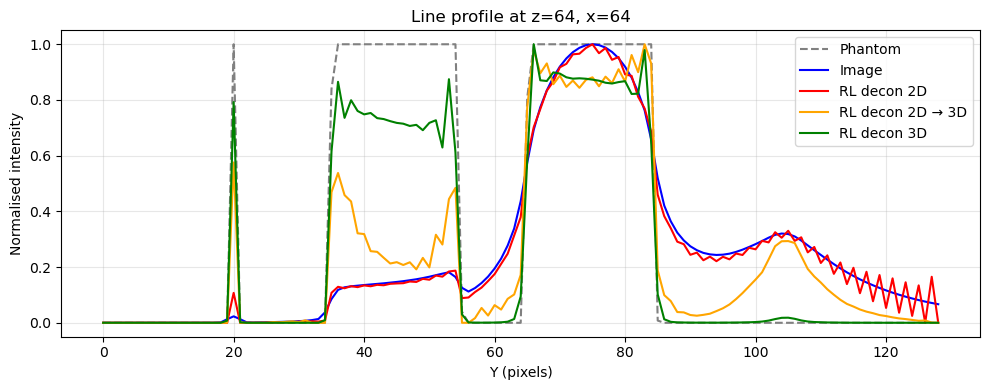

In [21]:
xc = phantom.shape[2]//2
yc = phantom.shape[1]//2
zc = phantom.shape[0]//2

profile_phantom = phantom[zc, :, xc]
profile_image   = image[zc, :, xc]
profile_decon_2d  = deconvolved_2d[:, xc]
profile_decon_2d_3d  = deconvolved_2d_3d[0, :, xc]
profile_decon_3d  = deconvolved_3d[zc, :, xc]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profile_phantom/profile_phantom.max(), label='Phantom', color='gray', linestyle='--')
ax.plot(profile_image/profile_image.max(),   label='Image',   color='blue')
ax.plot(profile_decon_2d/profile_decon_2d.max(),   label='RL decon 2D', color='red')
ax.plot(profile_decon_2d_3d/profile_decon_2d_3d.max(),   label='RL decon 2D → 3D', color='orange')
ax.plot(profile_decon_3d/profile_decon_3d.max(),   label='RL decon 3D', color='green')
ax.set_xlabel('Y (pixels)')
ax.set_ylabel('Normalised intensity')
ax.set_title(f'Line profile at z={zc}, x={xc}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Input size: (1, 129, 129), PSF size: (75, 95, 95)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0# 250# 500# 750# 1000# 1250# 1500# 1750# 2000# 2250# 
(75, 224, 224)


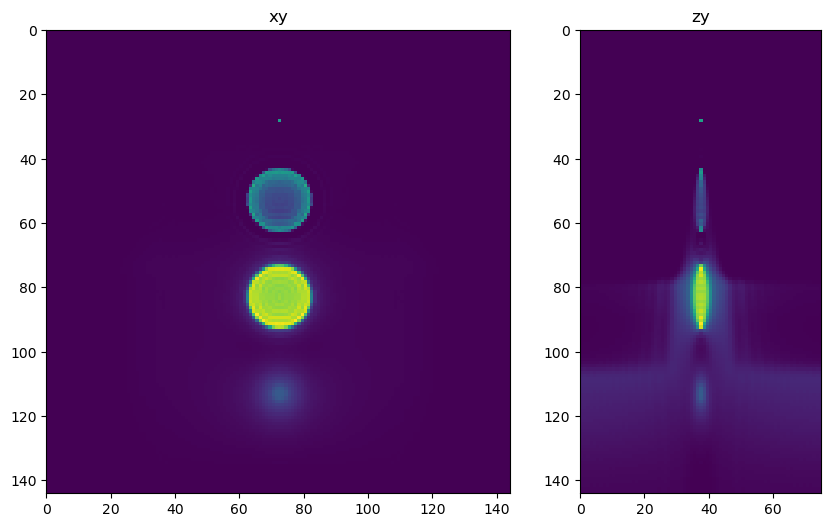

In [17]:
deconvolved_2d_3d_full, _ = richardson_lucy_cp(input_slice, psf, 2500, noncirc=True, do_unpad=False)
s=deconvolved_2d_3d_full.shape
print(s)
b=40
fig = show_xy_zy_slice_center(deconvolved_2d_3d_full[:,b:s[2]-b, b:s[2]-b], figsize=(10,10))